# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [7]:
from __future__ import annotations

import torch
import math
from torch import nn
import matplotlib.pyplot as plt
import seaborn as sns

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [8]:
def fan_in_fan_out(weight: torch.Tensor) -> tuple[int, int]:
    """Compute (fan_in, fan_out) for a weight tensor."""
    dimensions = weight.ndim
    if dimensions < 2:
        num_input_fmaps = weight.numel()
        num_output_fmaps = weight.numel()
        return num_input_fmaps, num_output_fmaps

    num_input_fmaps = weight.size(1)
    num_output_fmaps = weight.size(0)

    receptive_field_size = 1
    if dimensions > 2:
        for s in weight.shape[2:]:
            receptive_field_size *= s

    fan_in = num_input_fmaps * receptive_field_size
    fan_out = num_output_fmaps * receptive_field_size

    return fan_in, fan_out

def xavier_uniform_(weight: torch.Tensor, gain: float = 1.0) -> torch.Tensor:
    """
    In-place Xavier/Glorot uniform init:
      bound = gain * sqrt(6 / (fan_in + fan_out))
      U(-bound, bound)
    """
    fan_in, fan_out = fan_in_fan_out(weight)
    
    bound = gain * math.sqrt(6.0 / (fan_in + fan_out))

    with torch.no_grad():
        weight.uniform_(-bound, bound)
        
    return weight

class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        w = torch.empty(self.out_features, self.in_features, dtype=torch.float32)
        self.weights = nn.Parameter(xavier_uniform_(w))

        if bias:
            self.bias = nn.Parameter(torch.zeros(out_features))
        else:
            self.register_parameter("bias", None)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        y = x @ self.weights.T
        if self.bias is not None:
            y += self.bias
        return y

# x is a batch of inputs
x = torch.tensor([[1, 2, 3, 4],
                  [6, 7, 8, 1],
                  [2, 3, 4, 5],
                  [7, 2, 3, 2]], dtype=torch.float32)

linear_layer = Linear(in_features=4, out_features=2)
print(linear_layer(x))
print(linear_layer.weights.shape)
print(linear_layer.bias.shape)

tensor([[-2.0195,  1.0250],
        [-1.0620,  0.9080],
        [-2.7257,  1.4239],
        [-2.6176,  4.4668]], grad_fn=<AddBackward0>)
torch.Size([2, 4])
torch.Size([2])


In [9]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim

        w = torch.empty(self.num_embeddings, self.embedding_dim)
        self.weights = nn.Parameter(xavier_uniform_(w))

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        return self.weights[idx]

embedding_layer = Embedding(4, 9)
print(embedding_layer(2))
print(embedding_layer.weights.shape)

tensor([-0.3015, -0.0473,  0.0257, -0.3794,  0.3090,  0.3558,  0.6336, -0.5792,
         0.6783], grad_fn=<SelectBackward0>)
torch.Size([4, 9])


In [10]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        if not self.training or self.p == 0:
            return x

        mask = (torch.rand_like(x) >= self.p).to(x.dtype)
        return (x*mask) / (1 - self.p)

x = torch.tensor([[1, 2, 3, 4],
                  [4, 5, 3, 2],
                  [3, 2, 4, 1]], dtype=torch.float32)
dropout_layer = Dropout(0.5)
dropout_layer(x)

tensor([[ 2.,  0.,  0.,  0.],
        [ 8., 10.,  6.,  4.],
        [ 6.,  4.,  8.,  0.]])

## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [11]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.elementwise_affine = elementwise_affine

        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True)

        x_norm = (x - mean) / torch.sqrt(var + self.eps)

        return self.weight * x_norm + self.bias
    
x = torch.tensor([[1, 2, 3, 4],
                  [4, 5, 3, 2],
                  [3, 2, 4, 1]], dtype=torch.float32)
layer_norm = LayerNorm(4)
layer_norm(x)

tensor([[-1.1619, -0.3873,  0.3873,  1.1619],
        [ 0.3873,  1.1619, -0.3873, -1.1619],
        [ 0.3873, -0.3873,  1.1619, -1.1619]], grad_fn=<AddBackward0>)

In [12]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps

        self.weight = nn.Parameter(torch.ones(normalized_shape))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        ms = (x**2).mean(dim=-1, keepdim=True)
        x_norm = x / torch.sqrt(ms + self.eps)
        return self.weight * x_norm

x = torch.tensor([[1, 2, 3, 4],
                  [4, 5, 3, 2],
                  [3, 2, 4, 1]], dtype=torch.float32)
rms_norm = RMSNorm(4)
rms_norm(x)

tensor([[0.3651, 0.7303, 1.0954, 1.4606],
        [1.0887, 1.3608, 0.8165, 0.5443],
        [1.0954, 0.7303, 1.4606, 0.3651]], grad_fn=<MulBackward0>)

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [13]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()

        layers_lst = [Linear(in_dim, hidden_dim)]
        if use_layernorm:
            layers_lst.append(LayerNorm(hidden_dim))
        layers_lst.append(nn.GELU())
        for i in range(depth):
            layers_lst.append(Linear(hidden_dim, hidden_dim))
            if use_layernorm:
                layers_lst.append(LayerNorm(hidden_dim))
            layers_lst.append(nn.GELU())

        layers_lst.append(Linear(hidden_dim, out_dim))
        if use_layernorm:
            layers_lst.append(LayerNorm(out_dim))
        layers_lst.append(nn.GELU())

        self.layers = nn.ModuleList(layers_lst)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x)

        return x

x = torch.tensor([[1, 2, 3],
                  [3, 4, 5],
                  [1, 3, 4],
                  [3, 4, 5]], dtype=torch.float32)

mlp = MLP(3, 4, 2, 2, True)
mlp(x)

tensor([[ 0.5374, -0.1695],
        [ 0.5371, -0.1695],
        [ 0.5375, -0.1695],
        [ 0.5371, -0.1695]], grad_fn=<GeluBackward0>)

In [14]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.layers = nn.Sequential(
            Linear(d_model, d_ff),
            nn.GELU(),
            Linear(d_ff, d_model),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)


x = torch.tensor([[1, 2, 3],
                  [3, 4, 5],
                  [1, 3, 4],
                  [3, 4, 5]], dtype=torch.float32)

ffn = FeedForward(3)
ffn(x)

tensor([[ 0.2299, -0.1630,  0.9611],
        [ 0.2690, -0.0898,  2.8393],
        [ 0.3183, -0.1551,  1.3901],
        [ 0.2690, -0.0898,  2.8393]], grad_fn=<GeluBackward0>)

In [15]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        self.model = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        return x + self.model(x)

x = torch.tensor([[1, 2, 3],
                  [3, 4, 5],
                  [1, 3, 4],
                  [3, 4, 5]], dtype=torch.float32)

residual = Residual(ffn)
residual(x)

tensor([[1.2299, 1.8370, 3.9611],
        [3.2690, 3.9102, 7.8393],
        [1.3183, 2.8449, 5.3901],
        [3.2690, 3.9102, 7.8393]], grad_fn=<AddBackward0>)

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [16]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [17]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

data_loader_train = DataLoader(
    dataset=train_ds,
    batch_size=16,
    shuffle=True,
)

data_loader_test = DataLoader(
    dataset=test_ds,
    batch_size=16,
    shuffle=False
)

In [18]:
iterator = iter(data_loader_train)
next_value = next(iterator)

In [19]:
type(next_value)

list

In [20]:
next_value[0].shape

torch.Size([16, 1, 28, 28])

In [21]:
next_value[1].shape

torch.Size([16])

In [22]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    max_logits = logits.max(dim=-1, keepdim=True).values
    stabilized_logits = logits - max_logits
    log_sum_exp = torch.log(
        torch.sum(torch.exp(stabilized_logits), dim=-1, keepdim=True)
    )
    log_probs = stabilized_logits - log_sum_exp

    target_log_probs = log_probs.gather(dim=1, index=targets.unsqueeze(1))

    loss = -target_log_probs.mean()

    return loss

In [23]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        self.model = MLP(d_in, 2*d_in, num_classes, 3, True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        # x: (B, 1, 28, 28)
        x = torch.flatten(x, 1)
        # x: (B, 1x28x28)
        return self.model(x)

In [24]:
def accuracy(model, loader):
    model.eval()
    total = 0
    correct = 0

    with torch.no_grad():
        for input, target in loader:

            output = model(input)

            _, predicted = torch.max(output, dim=1)

            total += target.size(0)
            correct += (predicted == target).sum().item()

    if total == 0:
        return 0.0

    return correct/total

In [32]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """
    model.train()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr
    )
    losses = []
    for epoch in range(epochs):
        loss_tmp = 0.0
        for inputs, targets in train_data_loader:
            optimizer.zero_grad()

            predictions = model(inputs)
            loss = cross_entropy_from_logits(predictions, targets)
            loss_tmp += loss.item()

            loss.backward()
            optimizer.step()

        acc = accuracy(model, test_data_loader)
        print(f'Test accuracy for epoch: {epoch}: {acc}')

        losses.append(loss_tmp / len(train_data_loader))

    return losses


In [33]:
in_dim = 28*28
model = ClassificationHead(d_in=in_dim, num_classes=10)

losses = train_classifier(
    model,
    data_loader_train,
    data_loader_test,
    lr=1e-5,
    epochs=10,
)

Test accuracy for epoch: 0: 0.876
Test accuracy for epoch: 1: 0.8833
Test accuracy for epoch: 2: 0.8862
Test accuracy for epoch: 3: 0.8865
Test accuracy for epoch: 4: 0.8883
Test accuracy for epoch: 5: 0.8887
Test accuracy for epoch: 6: 0.8897
Test accuracy for epoch: 7: 0.8883
Test accuracy for epoch: 8: 0.8896
Test accuracy for epoch: 9: 0.8882


In [34]:
losses[-10:-1]

[0.7969605834643047,
 0.6396283298810324,
 0.5837378160953521,
 0.5444101893266042,
 0.5134494361480078,
 0.48900281344652174,
 0.4683957085331281,
 0.45077477825482687,
 0.43568734480142596]

<Axes: >

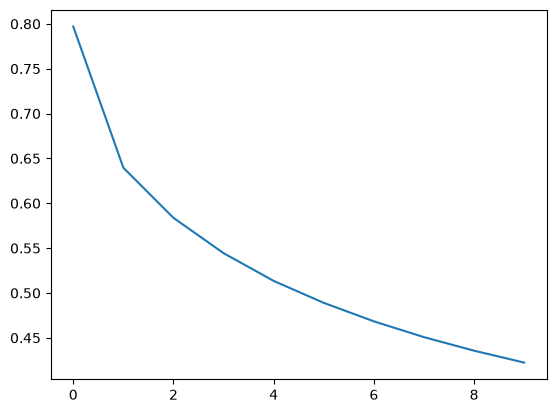

In [35]:
sns.lineplot(losses)

Finally, let's see an example

In [43]:
test_value = next(iter(data_loader_test))
test_value[1].shape

torch.Size([16])

In [49]:
predicted_values = model(test_value[0])
_, predicted_values = torch.max(predicted_values, dim=1)
predicted_values

tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 7, 9, 0, 1, 5])

In [45]:
test_value[0].shape

torch.Size([16, 1, 28, 28])

In [46]:
def plot_mnist_grid(
    batch,
    predicted_values,
    grid = (4, 4)
):
    images = batch[0]
    real = batch[1]

    rows, cols = grid
    num_images = rows*cols

    fig, axes = plt.subplots(rows, cols, figsize=(8, 8))
    axes = axes.flatten()

    for i in range(num_images):
        ax = axes[i]

        img = images[i].squeeze().cpu().detach().numpy()
        real_label = real[i].item()

        ax.imshow(img, cmap='gray')
        ax.axis('off')

        if predicted_values is not None:
            pred_label = predicted_values[i].item()
            is_correct = pred_label == real_label

            title=f'Pred: {pred_label}\nReal: {real_label}'
            color = 'green' if is_correct else 'red'
            ax.set_title(title, fontsize=10, color=color, fontweight='bold')
        else:
            ax.set_title(f'Real: {real_label}', fontsize=10)

    plt.tight_layout()
    plt.show()

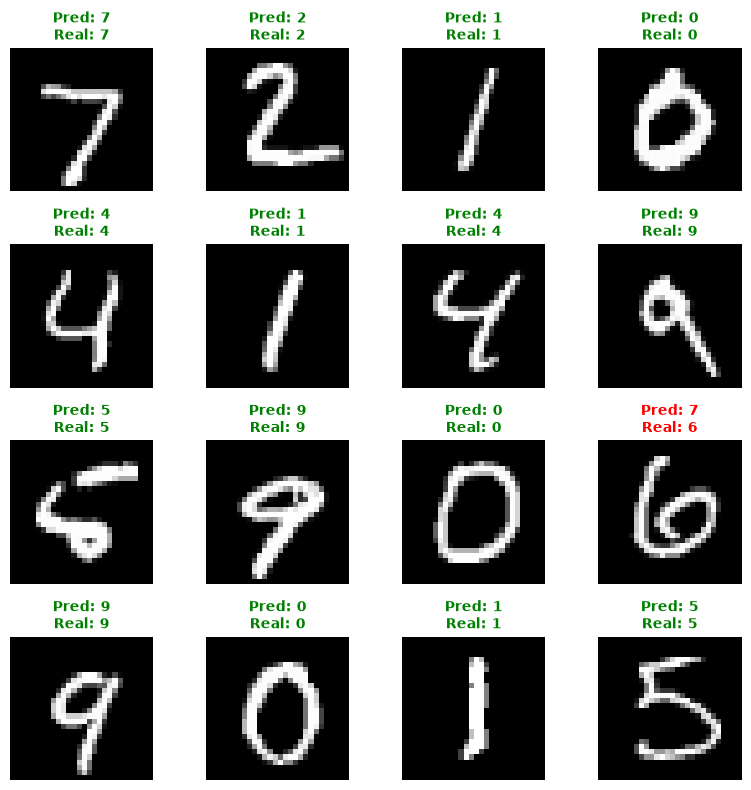

In [50]:
plot_mnist_grid(test_value,predicted_values)